# Quantum-Kernel External Validation: QSVC vs Matched Classical Baselines

**Project:** Gut Microbiome-Based Colorectal Cancer Classification  
**Discovery cohort:** Zeller et al. (2014), curatedMetagenomicData  
**Task:** Healthy vs CRC; Adenoma excluded  
**Discovery split:** 92 training / 22 held-out internal test samples  
**Seed:** 1910  
**Matched feature space:** the exact 8-feature subset already selected in the discovery-only QSVC analysis

## Scientific objective

This notebook performs a genuine **external validation** of the existing exploratory QSVC pipeline.

The frozen discovery pipeline is:

1. Zeller Healthy-vs-CRC discovery cohort.
2. Existing 20-feature Boruta-selected representation.
3. Existing training-only Random Forest Gini ranking of those 20 features.
4. Existing fixed top-8 feature list.
5. Existing training-fitted 8-feature angle scaler (`[0, 2π]`).
6. Existing QSVC artifact.
7. A matched 8-feature classical RBF SVM.
8. A matched 8-feature Logistic Regression comparator.

The frozen models and transformations are then applied, without feature selection or preprocessing refitting, to two independent external cohorts:

- FengQ_2015
- VogtmannE_2016

No external cohort is used for feature selection, scaler fitting, hyperparameter tuning, threshold adjustment, or model retraining.

**Important:** this notebook does not overwrite the original 20-feature classical models or the existing QSVC notebook. All new results use `QSVC_External_...` filenames inside the existing `03 Quantum_ML/05 QSVC/` folders.


## Notebook navigation

1. [Introduction](#Introduction)
2. [Research Objective](#Research-Objective)
3. [Workflow](#Workflow)
4. [Reproducibility and Environment](#Reproducibility-and-Environment)
5. [Analysis](#Analysis)
6. [Validation and Results](#Validation-and-Results)
7. [Saved Outputs](#Saved-Outputs)
8. [Session Information](#Session-Information)

**Project seed:** `1910`  
**Task:** Healthy vs CRC; adenoma excluded  
**Discovery split:** 92 training / 22 held-out test samples

> **Reproducibility contract.** This notebook does not install unpinned packages. Use `requirements.txt` to create the validated Python environment first. Every important table, figure, model artifact, and provenance record is saved under `results/`, `figures/`, or `models/`.


## Environment compatibility gate

The next code cell checks the exact Python/package versions recorded by the validated QSVC analysis. It intentionally stops rather than installing a newer package automatically.

```python
from importlib import metadata as importlib_metadata
import platform

EXPECTED_PYTHON = "3.14.6"
EXPECTED_PACKAGES = {
    "qiskit": "2.5.1",
    "qiskit-machine-learning": "0.9.0",
    "qiskit-aer": "0.17.2",
    "scikit-learn": "1.9.0",
    "numpy": "2.5.1",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "joblib": "1.5.3",
}

if platform.python_version() != EXPECTED_PYTHON:
    raise RuntimeError(
        f"Validated analysis used Python {EXPECTED_PYTHON}; "
        f"this kernel is {platform.python_version()}. "
        "Create the pinned environment from requirements.txt."
    )

missing_or_mismatched = {}
for package, expected in EXPECTED_PACKAGES.items():
    try:
        actual = importlib_metadata.version(package)
    except importlib_metadata.PackageNotFoundError:
        actual = "NOT INSTALLED"
    if actual != expected:
        missing_or_mismatched[package] = {"expected": expected, "found": actual}

if missing_or_mismatched:
    raise RuntimeError(
        "Validated QSVC environment mismatch. "
        "Install requirements.txt in a clean Python 3.14.6 environment before running."
        f" Details: {missing_or_mismatched}"
    )

print("Environment compatibility gate passed.")
```


## Section 1 — Scope and Methodological Safeguards

### What this cell does

Defines exactly what counts as a valid external-validation run.

### Key safeguards

- The discovery train/test split remains the project's existing 92/22 split.
- The exact existing top-8 feature list is loaded from disk and **not recalculated** here.
- The angle scaler is loaded from the existing fitted artifact and is **not refit**.
- The existing QSVC and SVM artifacts are loaded rather than retrained.
- The matched Logistic Regression is reconstructed from the frozen discovery training data because the previous notebook did not save its model object.
- The internal test set is first used as a reproducibility gate. External prediction does not begin unless the loaded QSVC and SVM reproduce the existing saved internal results within tolerance.
- External cohorts are used only for prediction/evaluation.


In [1]:
# ==========================================================
# Section 1: Project configuration
# ==========================================================

from pathlib import Path
import os
import sys
import json
import time
import random
import hashlib
import warnings
import platform
import importlib.metadata as importlib_metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    matthews_corrcoef,
)

warnings.filterwarnings("ignore")

SEED = 1910
random.seed(SEED)
np.random.seed(SEED)

# The notebook is intended to be run from:
# 03 Quantum_ML/05 QSVC/
project_root = Path(".").resolve()

data_dir = project_root / "data"
models_dir = project_root / "models"
results_dir = project_root / "results"
figures_dir = project_root / "figures"

for d in (data_dir, models_dir, results_dir, figures_dir):
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Data dir    :", data_dir)
print("Models dir  :", models_dir)
print("Results dir :", results_dir)
print("Figures dir :", figures_dir)
print("Random seed :", SEED)


Project root: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC
Data dir    : C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\data
Models dir  : C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\models
Results dir : C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results
Figures dir : C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures
Random seed : 1910


## Section 2 — Python and Quantum-Package Compatibility Gate

### What this cell does

Records the actual installed versions **before** the quantum model is loaded and checks that the imports required by the existing QSVC artifact are available.

Do **not** install packages in this notebook. The previous notebook used unpinned minimum-version installation commands, which is not adequate for a reproducible validation run because Qiskit APIs have changed across releases.

Qiskit Machine Learning 0.8+ requires Qiskit 1.0+, and the current Qiskit documentation identifies `StatevectorSampler` as the statevector-simulation implementation of the V2 sampler interface. The existing QSVC pipeline uses `StatevectorSampler`, `ComputeUncompute`, `FidelityQuantumKernel`, and `QSVC`. The exact installed versions recorded by this cell are the versions that must be reported for the run.

The simulator is **not Qiskit Aer**. The existing quantum model uses the Qiskit `StatevectorSampler`, i.e. ideal, noiseless classical statevector simulation.


In [2]:
# ==========================================================
# Section 2: Record package versions and test required imports
# ==========================================================

def package_version(package_name):
    try:
        return importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        return "NOT INSTALLED"

packages_to_record = [
    "python",
    "qiskit",
    "qiskit-machine-learning",
    "qiskit-aer",
    "scikit-learn",
    "numpy",
    "pandas",
    "matplotlib",
    "joblib",
]

version_rows = [{"Package": "python", "Version": platform.python_version()}]
for pkg in packages_to_record[1:]:
    version_rows.append({"Package": pkg, "Version": package_version(pkg)})

package_versions_df = pd.DataFrame(version_rows)
print(package_versions_df.to_string(index=False))

# Minimum compatibility requirements used by the existing QSVC notebook.
# These are gates, not automatic installations.
from packaging.version import Version

qiskit_v = package_version("qiskit")
qml_v = package_version("qiskit-machine-learning")
aer_v = package_version("qiskit-aer")
sklearn_v = package_version("scikit-learn")

assert qiskit_v != "NOT INSTALLED", "Qiskit is not installed."
assert qml_v != "NOT INSTALLED", "qiskit-machine-learning is not installed."
assert aer_v != "NOT INSTALLED", "qiskit-aer is not installed."
assert sklearn_v != "NOT INSTALLED", "scikit-learn is not installed."

assert Version(qiskit_v) >= Version("1.0"), f"Qiskit {qiskit_v} is below the required 1.0 baseline."
assert Version(qml_v) >= Version("0.8"), f"Qiskit Machine Learning {qml_v} is below the required 0.8 baseline."
assert Version(aer_v) >= Version("0.14"), f"Qiskit Aer {aer_v} is below the required 0.14 baseline."
assert Version(sklearn_v) >= Version("1.3"), f"scikit-learn {sklearn_v} is below the required 1.3 baseline."

# Required imports for the serialized QSVC artifact.
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

print("\nRequired Qiskit/QML imports succeeded.")
print("Quantum simulator/backend used by the frozen model: StatevectorSampler (ideal noiseless statevector simulation).")
print("Qiskit Aer is recorded for reproducibility but is NOT the backend used by this analysis.")

package_versions_df.to_csv(
    results_dir / "QSVC_External_Validation_PackageVersions.csv",
    index=False
)
print("Saved:", results_dir / "QSVC_External_Validation_PackageVersions.csv")


                Package Version
                 python  3.14.6
                 qiskit   2.5.1
qiskit-machine-learning   0.9.0
             qiskit-aer  0.17.2
           scikit-learn   1.9.0
                  numpy   2.5.1
                 pandas   3.0.5
             matplotlib  3.11.1
                 joblib   1.5.3

Required Qiskit/QML imports succeeded.
Quantum simulator/backend used by the frozen model: StatevectorSampler (ideal noiseless statevector simulation).
Qiskit Aer is recorded for reproducibility but is NOT the backend used by this analysis.
Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_External_Validation_PackageVersions.csv


## Section 3 — Input Artifact Audit

### What this cell does

Checks that every file required by the external-validation reconstruction exists before any external prediction is attempted.

The notebook deliberately distinguishes:

- **existing discovery artifacts** that must remain untouched;
- **new matched Logistic Regression artifact**, because the original Python notebook saved its metrics and predictions but did not save the fitted Logistic Regression object;
- **new external cohort data exports**, produced by the separate R prerequisite file.

If any required input is missing, the notebook stops here rather than silently substituting another file.


In [3]:
# ==========================================================
# Section 3: Required-artifact audit
# ==========================================================

required_existing_files = [
    data_dir / "QSVC_Train_Data.csv",
    data_dir / "QSVC_Test_Data.csv",
    data_dir / "QSVC_Feature_Name_Map.csv",
    results_dir / "QSVC_Selected_Top8_Features.csv",
    results_dir / "QSVC_Test_Metrics.csv",
    results_dir / "QSVC_vs_ClassicalSVM_Comparison.csv",
    results_dir / "QSVC_vs_LogisticRegression_8Feature_Comparison.csv",
    models_dir / "QSVC_AngleScaler.joblib",
    models_dir / "QSVC_Model.joblib",
    models_dir / "QSVC_ClassicalSVM_Baseline.joblib",
]

external_input_files = [
    data_dir / "QSVC_External_FengQ_2015_Data.csv",
    data_dir / "QSVC_External_VogtmannE_2016_Data.csv",
]

all_required = required_existing_files + external_input_files

audit_rows = []
for p in all_required:
    audit_rows.append({
        "Path": str(p),
        "Exists": p.exists(),
        "Size_bytes": p.stat().st_size if p.exists() else np.nan,
    })

artifact_audit_df = pd.DataFrame(audit_rows)
print(artifact_audit_df.to_string(index=False))

missing = artifact_audit_df.loc[~artifact_audit_df["Exists"], "Path"].tolist()
assert not missing, (
    "Required artifact(s) missing. Run the separate "
    "QSVC_External_Validation_Prerequisite.Rmd first if the external data files are absent.\n"
    + "\n".join(missing)
)

artifact_audit_df.to_csv(
    results_dir / "QSVC_External_Validation_Artifact_Audit.csv",
    index=False
)
print("\nAll required artifacts found.")


                                                                                                                                                  Path  Exists  Size_bytes
                                  C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\data\QSVC_Train_Data.csv    True       39748
                                   C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\data\QSVC_Test_Data.csv    True       11447
                            C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\data\QSVC_Feature_Name_Map.csv    True        5084
                   C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_Selected_Top8_Features.csv    True        1214
                             C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_Test_Metric

## Section 4 — Load the Frozen Discovery Representation

### What this cell does

Loads the existing R-exported discovery train/test representation and the existing top-8 feature list.

### Important methodological point

The top-8 features are **not selected again** here. The existing file `QSVC_Selected_Top8_Features.csv` is treated as a frozen discovery artifact.

This matters because an external validation must not use the external cohorts to decide which features are useful.


In [4]:
# ==========================================================
# Section 4: Load discovery artifacts
# ==========================================================

train_df = pd.read_csv(data_dir / "QSVC_Train_Data.csv")
test_df = pd.read_csv(data_dir / "QSVC_Test_Data.csv")

top8_df = pd.read_csv(results_dir / "QSVC_Selected_Top8_Features.csv")
feature_map_df = pd.read_csv(data_dir / "QSVC_Feature_Name_Map.csv")

assert train_df.shape[0] == 92, f"Expected 92 training samples, got {train_df.shape[0]}"
assert test_df.shape[0] == 22, f"Expected 22 test samples, got {test_df.shape[0]}"
assert len(top8_df) == 8, f"Expected exactly 8 frozen selected features, got {len(top8_df)}"

top8_features = top8_df["Syntactic_Feature"].tolist()

assert len(set(top8_features)) == 8
assert set(top8_features).issubset(train_df.columns)
assert set(top8_features).issubset(test_df.columns)

print("Discovery training shape:", train_df.shape)
print("Discovery test shape    :", test_df.shape)
print("\nFrozen Top-8 features:")
print(top8_df.to_string(index=False))

print("\nFeature count:", len(top8_features))


Discovery training shape: (92, 22)
Discovery test shape    : (22, 22)

Frozen Top-8 features:
 Rank                                                                                                                       Syntactic_Feature  Importance
    1  k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Peptostreptococcaceae.g__Peptostreptococcus.s__Peptostreptococcus_stomatis    0.094109
    2                k__Bacteria.p__Firmicutes.c__Bacilli.o__Lactobacillales.f__Streptococcaceae.g__Streptococcus.s__Streptococcus_salivarius    0.083404
    3                       k__Bacteria.p__Firmicutes.c__Tissierellia.o__Tissierellales.f__Peptoniphilaceae.g__Parvimonas.s__Parvimonas_micra    0.059185
    4      k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Ruminococcaceae.g__Ruthenibacterium.s__Ruthenibacterium_lactatiformans    0.056907
    5                      k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Lachnospiraceae.g__Anaerostipes.s__Anaerostipes_h

## Section 5 — Label and Feature Integrity Checks

### What this cell does

Confirms that the discovery representation is still:

- Healthy vs CRC only;
- Healthy = 0 and CRC = 1;
- 20 discovery features before the frozen 20→8 reduction;
- no missing values;
- unique sample identifiers.

The binary task is the same as the manuscript: 114 Zeller samples total, split into 92 training and 22 held-out internal test samples.


In [5]:
# ==========================================================
# Section 5: Discovery integrity
# ==========================================================

non_feature_cols = {"SampleID", "disease"}
feature_cols_20 = [c for c in train_df.columns if c not in non_feature_cols]

assert len(feature_cols_20) == 20
assert feature_cols_20 == [c for c in test_df.columns if c not in non_feature_cols]

assert set(train_df["disease"]) == {"healthy", "CRC"}
assert set(test_df["disease"]) == {"healthy", "CRC"}

assert train_df["SampleID"].is_unique
assert test_df["SampleID"].is_unique

assert train_df[feature_cols_20].notna().all().all()
assert test_df[feature_cols_20].notna().all().all()

class_to_int = {"healthy": 0, "CRC": 1}
y_train = train_df["disease"].map(class_to_int).to_numpy()
y_test = test_df["disease"].map(class_to_int).to_numpy()

X_train_20 = train_df[feature_cols_20].copy()
X_test_20 = test_df[feature_cols_20].copy()

X_train_8 = train_df[top8_features].copy()
X_test_8 = test_df[top8_features].copy()

print("20-feature training matrix:", X_train_20.shape)
print("20-feature test matrix    :", X_test_20.shape)
print("8-feature training matrix :", X_train_8.shape)
print("8-feature test matrix     :", X_test_8.shape)
print("\nTraining class counts:", train_df["disease"].value_counts().to_dict())
print("Test class counts    :", test_df["disease"].value_counts().to_dict())


20-feature training matrix: (92, 20)
20-feature test matrix    : (22, 20)
8-feature training matrix : (92, 8)
8-feature test matrix     : (22, 8)

Training class counts: {'healthy': 49, 'CRC': 43}
Test class counts    : {'healthy': 12, 'CRC': 10}


## Section 6 — Load Frozen Transformation and Model Artifacts

### What this cell does

Loads:

- the existing 8-feature angle scaler;
- the existing QSVC;
- the existing same-feature-space classical RBF SVM.

The frozen angle scaler is **not refit** on the external cohorts.

The QSVC is the same serialized model used for the existing exploratory internal analysis. Therefore, loading it successfully is a prerequisite for calling this a validation of the existing QSVC rather than a newly tuned model.


In [6]:
# ==========================================================
# Section 6: Load frozen model artifacts
# ==========================================================

angle_scaler = joblib.load(models_dir / "QSVC_AngleScaler.joblib")
qsvc = joblib.load(models_dir / "QSVC_Model.joblib")
classical_svm_8 = joblib.load(models_dir / "QSVC_ClassicalSVM_Baseline.joblib")

print("Loaded:")
print("  QSVC angle scaler:", type(angle_scaler).__name__)
print("  QSVC model       :", type(qsvc).__name__)
print("  Classical SVM    :", type(classical_svm_8).__name__)

assert hasattr(angle_scaler, "transform")
assert hasattr(qsvc, "predict")
assert hasattr(qsvc, "decision_function")
assert hasattr(classical_svm_8, "predict")
assert hasattr(classical_svm_8, "decision_function")

# Confirm the angle scaler was fitted on exactly 8 features.
assert getattr(angle_scaler, "n_features_in_", None) == 8
print("Angle scaler n_features_in_:", angle_scaler.n_features_in_)


Loaded:
  QSVC angle scaler: MinMaxScaler
  QSVC model       : QSVC
  Classical SVM    : SVC
Angle scaler n_features_in_: 8


## Section 7 — Reconstruct the Matched 8-Feature Logistic Regression

### Why this model is rebuilt

The earlier notebook saved the 8-feature Logistic Regression metrics and predictions, but it did **not** save a fitted Logistic Regression model artifact.

Rebuilding it from the exact same 92 discovery training samples, exact same frozen top-8 feature list, and same parameters is a reproducible reconstruction. It does not use external data.

The fitted model is saved now so that this external-validation run has a frozen Logistic Regression artifact as well.


In [7]:
# ==========================================================
# Section 7: Reconstruct and save matched 8-feature Logistic Regression
# ==========================================================

lr_model = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)

lr_model.fit(X_train_8, y_train)

lr_model_path = models_dir / "QSVC_Matched_LogisticRegression_8Feature_Model.joblib"
joblib.dump(lr_model, lr_model_path)

print("Saved:", lr_model_path)


Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\models\QSVC_Matched_LogisticRegression_8Feature_Model.joblib


## Section 8 — Common Metric Function

### What this cell does

Defines one binary-metric function used for the internal reproducibility gate and both external cohorts.

The positive class is always **CRC**.

ROC-AUC is calculated from the model's continuous score:

- Logistic Regression: predicted CRC probability.
- Classical SVM: SVM decision function.
- QSVC: QSVC decision function.

QSVC and the classical RBF SVM do not provide calibrated probabilities here, so their ROC-AUC values must not be described as probability-calibrated performance.


In [8]:
# ==========================================================
# Section 8: Common binary metrics
# ==========================================================

def compute_binary_metrics(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall_Sensitivity": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Specificity": specificity,
        "F1_Score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

METRIC_COLUMNS = [
    "Accuracy",
    "Precision",
    "Recall_Sensitivity",
    "Specificity",
    "F1_Score",
    "ROC_AUC",
    "MCC",
]


## Section 9 — Internal Held-Out Test Reproducibility Gate

### This is an important scientific control

Before any external cohort is touched for prediction, the notebook reproduces the existing internal 22-sample test results.

Expected values from the saved project outputs are:

- QSVC AUC ≈ 0.6083
- matched SVM AUC = 0.6000
- matched Logistic Regression AUC ≈ 0.7083

The exact values are read from the project's saved CSV files and compared to this reconstruction.

If the frozen QSVC or SVM does not reproduce its saved internal metrics, the notebook **stops**. That prevents a Qiskit-version mismatch or model-serialization change from being mistaken for genuine external-validation behavior.


In [9]:
# ==========================================================
# Section 9: Internal reproducibility gate
# ==========================================================

X_test_8_angle = angle_scaler.transform(X_test_8)

# ----------------------------------------------------------
# 1. Reconstruct internal predictions from frozen models
# ----------------------------------------------------------

# QSVC
internal_qsvc_pred = qsvc.predict(X_test_8_angle)
internal_qsvc_score = qsvc.decision_function(X_test_8_angle)

internal_qsvc_metrics = compute_binary_metrics(
    y_test,
    internal_qsvc_pred,
    internal_qsvc_score
)

# Matched classical SVM
internal_svm_pred = classical_svm_8.predict(X_test_8_angle)
internal_svm_score = classical_svm_8.decision_function(X_test_8_angle)

internal_svm_metrics = compute_binary_metrics(
    y_test,
    internal_svm_pred,
    internal_svm_score
)

# Matched Logistic Regression
internal_lr_pred = lr_model.predict(X_test_8)
internal_lr_score = lr_model.predict_proba(X_test_8)[:, 1]

internal_lr_metrics = compute_binary_metrics(
    y_test,
    internal_lr_pred,
    internal_lr_score
)

# ----------------------------------------------------------
# 2. Store reconstructed metrics
# ----------------------------------------------------------

internal_reconstructed = pd.DataFrame([
    {
        "Model": "QSVC (8 features)",
        **internal_qsvc_metrics
    },
    {
        "Model": "Classical SVM (RBF, 8 features)",
        **internal_svm_metrics
    },
    {
        "Model": "Logistic Regression (8 features)",
        **internal_lr_metrics
    },
])

print("\nReconstructed internal metrics:")
print(internal_reconstructed.to_string(index=False))

# ----------------------------------------------------------
# 3. Load historical saved internal results
# ----------------------------------------------------------

saved_qsvc = pd.read_csv(
    results_dir / "QSVC_Test_Metrics.csv"
).iloc[0]

saved_svm_df = pd.read_csv(
    results_dir / "QSVC_vs_ClassicalSVM_Comparison.csv"
)

saved_lr_df = pd.read_csv(
    results_dir / "QSVC_vs_LogisticRegression_8Feature_Comparison.csv"
)

saved_svm = saved_svm_df.loc[
    saved_svm_df["Model"].str.contains(
        "Classical SVM",
        regex=False
    )
].iloc[0]

saved_lr = saved_lr_df.loc[
    saved_lr_df["Model"].str.contains(
        "Logistic Regression",
        regex=False
    )
].iloc[0]

expected = {
    "QSVC (8 features)": saved_qsvc,
    "Classical SVM (RBF, 8 features)": saved_svm,
    "Logistic Regression (8 features)": saved_lr,
}

# ----------------------------------------------------------
# 4. Metrics common to all historical saved files
# ----------------------------------------------------------
#
# MCC is intentionally excluded from this historical
# reproducibility gate because the saved Classical SVM
# comparison file does not contain MCC.
#
# MCC will still be calculated later for the new external
# validation predictions.

GATE_METRICS = [
    "Accuracy",
    "Precision",
    "Recall_Sensitivity",
    "Specificity",
    "F1_Score",
    "ROC_AUC",
]

# Numerical tolerance for comparing reconstructed
# floating-point metrics with historical saved values.
tolerance = 1e-10

# ----------------------------------------------------------
# 5. Compare reconstructed values with saved values
# ----------------------------------------------------------

comparison_rows = []

for _, reconstructed_row in internal_reconstructed.iterrows():

    model = reconstructed_row["Model"]
    saved_row = expected[model]

    for metric in GATE_METRICS:

        if metric not in reconstructed_row.index:
            raise KeyError(
                f"Metric '{metric}' is missing from reconstructed "
                f"results for model '{model}'."
            )

        if metric not in saved_row.index:
            raise KeyError(
                f"Metric '{metric}' is missing from saved results "
                f"for model '{model}'."
            )

        reconstructed_value = float(
            reconstructed_row[metric]
        )

        saved_value = float(
            saved_row[metric]
        )

        absolute_difference = abs(
            reconstructed_value - saved_value
        )

        comparison_rows.append({
            "Model": model,
            "Metric": metric,
            "Reconstructed": reconstructed_value,
            "Saved": saved_value,
            "Absolute_Difference": absolute_difference,
            "Pass": absolute_difference <= tolerance,
        })

internal_gate_df = pd.DataFrame(comparison_rows)

# ----------------------------------------------------------
# 6. Display reproducibility comparison
# ----------------------------------------------------------

print("\nInternal reproducibility comparison:")
print(internal_gate_df.to_string(index=False))

# ----------------------------------------------------------
# 7. Hard stop if any comparison fails
# ----------------------------------------------------------

assert internal_gate_df["Pass"].all(), (
    "Internal reproducibility gate FAILED. "
    "Do not continue to external validation. "
    "Investigate model serialization, package versions, "
    "preprocessing, and frozen artifacts first."
)

# ----------------------------------------------------------
# 8. Save reproducibility outputs
# ----------------------------------------------------------

internal_reconstructed.to_csv(
    results_dir /
    "QSVC_External_Validation_Internal_Reconstructed_Metrics.csv",
    index=False
)

internal_gate_df.to_csv(
    results_dir /
    "QSVC_External_Validation_Internal_Reproducibility_Gate.csv",
    index=False
)

# ----------------------------------------------------------
# 9. Success message
# ----------------------------------------------------------

print(
    "\nPASS: frozen internal results reproduced exactly "
    "within tolerance."
)


Reconstructed internal metrics:
                           Model  Accuracy  Precision  Recall_Sensitivity  Specificity  F1_Score  ROC_AUC      MCC
               QSVC (8 features)  0.545455   0.500000                 0.6     0.500000  0.545455 0.608333 0.100000
 Classical SVM (RBF, 8 features)  0.590909   0.571429                 0.4     0.750000  0.470588 0.600000 0.160357
Logistic Regression (8 features)  0.636364   0.666667                 0.4     0.833333  0.500000 0.708333 0.260875

Internal reproducibility comparison:
                           Model             Metric  Reconstructed    Saved  Absolute_Difference  Pass
               QSVC (8 features)           Accuracy       0.545455 0.545455         0.000000e+00  True
               QSVC (8 features)          Precision       0.500000 0.500000         0.000000e+00  True
               QSVC (8 features) Recall_Sensitivity       0.600000 0.600000         0.000000e+00  True
               QSVC (8 features)        Specificity      

## Section 10 — Load the Two External Cohort Exports

### What this cell does

Loads the two independent external cohorts exported using the **frozen discovery scaler and the frozen 20-feature discovery panel**.

The R prerequisite performs:

1. cohort loading from `curatedMetagenomicData`;
2. Healthy/CRC restriction;
3. use of the discovery 20-feature list;
4. application of the frozen discovery centering/scaling object;
5. conversion to the same Python-safe feature names used by the discovery QSVC export.

Nothing below refits those preprocessing steps.

This separation is important: the external data are transformed using discovery-derived parameters, not cohort-derived parameters.


In [10]:
# ==========================================================
# Section 9: Internal reproducibility gate
# ==========================================================

X_test_8_angle = angle_scaler.transform(X_test_8)

# ----------------------------------------------------------
# 1. Reconstruct internal predictions from frozen models
# ----------------------------------------------------------

# QSVC
internal_qsvc_pred = qsvc.predict(X_test_8_angle)
internal_qsvc_score = qsvc.decision_function(X_test_8_angle)

internal_qsvc_metrics = compute_binary_metrics(
    y_test,
    internal_qsvc_pred,
    internal_qsvc_score
)

# Matched classical SVM
internal_svm_pred = classical_svm_8.predict(X_test_8_angle)
internal_svm_score = classical_svm_8.decision_function(X_test_8_angle)

internal_svm_metrics = compute_binary_metrics(
    y_test,
    internal_svm_pred,
    internal_svm_score
)

# Matched Logistic Regression
internal_lr_pred = lr_model.predict(X_test_8)
internal_lr_score = lr_model.predict_proba(X_test_8)[:, 1]

internal_lr_metrics = compute_binary_metrics(
    y_test,
    internal_lr_pred,
    internal_lr_score
)

# ----------------------------------------------------------
# 2. Store reconstructed metrics
# ----------------------------------------------------------

internal_reconstructed = pd.DataFrame([
    {
        "Model": "QSVC (8 features)",
        **internal_qsvc_metrics
    },
    {
        "Model": "Classical SVM (RBF, 8 features)",
        **internal_svm_metrics
    },
    {
        "Model": "Logistic Regression (8 features)",
        **internal_lr_metrics
    },
])

print("\nReconstructed internal metrics:")
print(internal_reconstructed.to_string(index=False))

# ----------------------------------------------------------
# 3. Load historical saved internal results
# ----------------------------------------------------------

saved_qsvc = pd.read_csv(
    results_dir / "QSVC_Test_Metrics.csv"
).iloc[0]

saved_svm_df = pd.read_csv(
    results_dir / "QSVC_vs_ClassicalSVM_Comparison.csv"
)

saved_lr_df = pd.read_csv(
    results_dir / "QSVC_vs_LogisticRegression_8Feature_Comparison.csv"
)

saved_svm = saved_svm_df.loc[
    saved_svm_df["Model"].str.contains(
        "Classical SVM",
        regex=False
    )
].iloc[0]

saved_lr = saved_lr_df.loc[
    saved_lr_df["Model"].str.contains(
        "Logistic Regression",
        regex=False
    )
].iloc[0]

expected = {
    "QSVC (8 features)": saved_qsvc,
    "Classical SVM (RBF, 8 features)": saved_svm,
    "Logistic Regression (8 features)": saved_lr,
}

# ----------------------------------------------------------
# 4. Metrics common to all historical saved files
# ----------------------------------------------------------
#
# MCC is intentionally excluded from this historical
# reproducibility gate because the saved Classical SVM
# comparison file does not contain MCC.
#
# MCC will still be calculated later for the new external
# validation predictions.

GATE_METRICS = [
    "Accuracy",
    "Precision",
    "Recall_Sensitivity",
    "Specificity",
    "F1_Score",
    "ROC_AUC",
]

# Numerical tolerance for comparing reconstructed
# floating-point metrics with historical saved values.
tolerance = 1e-10

# ----------------------------------------------------------
# 5. Compare reconstructed values with saved values
# ----------------------------------------------------------

comparison_rows = []

for _, reconstructed_row in internal_reconstructed.iterrows():

    model = reconstructed_row["Model"]
    saved_row = expected[model]

    for metric in GATE_METRICS:

        if metric not in reconstructed_row.index:
            raise KeyError(
                f"Metric '{metric}' is missing from reconstructed "
                f"results for model '{model}'."
            )

        if metric not in saved_row.index:
            raise KeyError(
                f"Metric '{metric}' is missing from saved results "
                f"for model '{model}'."
            )

        reconstructed_value = float(
            reconstructed_row[metric]
        )

        saved_value = float(
            saved_row[metric]
        )

        absolute_difference = abs(
            reconstructed_value - saved_value
        )

        comparison_rows.append({
            "Model": model,
            "Metric": metric,
            "Reconstructed": reconstructed_value,
            "Saved": saved_value,
            "Absolute_Difference": absolute_difference,
            "Pass": absolute_difference <= tolerance,
        })

internal_gate_df = pd.DataFrame(comparison_rows)

# ----------------------------------------------------------
# 6. Display reproducibility comparison
# ----------------------------------------------------------

print("\nInternal reproducibility comparison:")
print(internal_gate_df.to_string(index=False))

# ----------------------------------------------------------
# 7. Hard stop if any comparison fails
# ----------------------------------------------------------

assert internal_gate_df["Pass"].all(), (
    "Internal reproducibility gate FAILED. "
    "Do not continue to external validation. "
    "Investigate model serialization, package versions, "
    "preprocessing, and frozen artifacts first."
)

# ----------------------------------------------------------
# 8. Save reproducibility outputs
# ----------------------------------------------------------

internal_reconstructed.to_csv(
    results_dir /
    "QSVC_External_Validation_Internal_Reconstructed_Metrics.csv",
    index=False
)

internal_gate_df.to_csv(
    results_dir /
    "QSVC_External_Validation_Internal_Reproducibility_Gate.csv",
    index=False
)

# ----------------------------------------------------------
# 9. Success message
# ----------------------------------------------------------

print(
    "\nPASS: frozen internal results reproduced exactly "
    "within tolerance."
)



Reconstructed internal metrics:
                           Model  Accuracy  Precision  Recall_Sensitivity  Specificity  F1_Score  ROC_AUC      MCC
               QSVC (8 features)  0.545455   0.500000                 0.6     0.500000  0.545455 0.608333 0.100000
 Classical SVM (RBF, 8 features)  0.590909   0.571429                 0.4     0.750000  0.470588 0.600000 0.160357
Logistic Regression (8 features)  0.636364   0.666667                 0.4     0.833333  0.500000 0.708333 0.260875

Internal reproducibility comparison:
                           Model             Metric  Reconstructed    Saved  Absolute_Difference  Pass
               QSVC (8 features)           Accuracy       0.545455 0.545455         0.000000e+00  True
               QSVC (8 features)          Precision       0.500000 0.500000         0.000000e+00  True
               QSVC (8 features) Recall_Sensitivity       0.600000 0.600000         0.000000e+00  True
               QSVC (8 features)        Specificity      

## Section 11 — External Feature and Sample Alignment Audit

### What this cell does

Creates an explicit audit showing that each external cohort contains the same frozen top-8 syntactic features in the same order.

It also checks that the external cohorts do not overlap with the discovery training or internal test sample IDs.

A failed audit means the validation cannot proceed.


In [11]:
# ==========================================================
# Section 10: External data loading
# ==========================================================

external_cohorts = {
    "FengQ_2015": data_dir / "QSVC_External_FengQ_2015_Data.csv",
    "VogtmannE_2016": data_dir / "QSVC_External_VogtmannE_2016_Data.csv",
}

external_data = {}

for cohort_name, path in external_cohorts.items():

    df = pd.read_csv(path)

    assert "SampleID" in df.columns
    assert "disease" in df.columns

    external_features = [
        c for c in df.columns
        if c not in {"SampleID", "disease"}
    ]

    assert len(external_features) == 20, (
        f"{cohort_name}: expected 20 frozen discovery features, "
        f"got {len(external_features)}"
    )

    assert set(df["disease"]) == {"healthy", "CRC"}

    assert df["SampleID"].is_unique

    assert df[external_features].notna().all().all()

    missing_top8 = sorted(
        set(top8_features) - set(df.columns)
    )

    assert not missing_top8, (
        f"{cohort_name}: frozen top-8 features missing: "
        f"{missing_top8}"
    )

    external_data[cohort_name] = df

    print(f"\n{cohort_name}")
    print("  Shape:", df.shape)
    print(
        "  Class counts:",
        df["disease"].value_counts().to_dict()
    )

    df.to_csv(
        data_dir /
        f"QSVC_External_{cohort_name}_Data_Audited.csv",
        index=False
    )

print("\nExternal cohort loading completed successfully.")



FengQ_2015
  Shape: (107, 22)
  Class counts: {'healthy': 61, 'CRC': 46}

VogtmannE_2016
  Shape: (104, 22)
  Class counts: {'healthy': 52, 'CRC': 52}

External cohort loading completed successfully.


## Section 12 — Transform the External Cohorts Using the Frozen Quantum Angle Scaler

### What this cell does

Applies the existing discovery-trained `MinMaxScaler(feature_range=(0, 2π))` to the top-8 standardized external features.

The scaler is **not fitted** on either external cohort.

The transformation is therefore:

**external raw cohort → frozen discovery 20-feature scaler in R → frozen top-8 selection → frozen quantum angle scaler in Python → QSVC**

This is exactly the kind of frozen-pipeline transfer required for external validation.


In [12]:
# ==========================================================
# Section 12: Frozen angle transformation
# ==========================================================

external_matrices = {}
external_angle_matrices = {}
external_labels = {}

for cohort_name, df in external_data.items():
    X_ext_8 = df[top8_features].copy()
    y_ext = df["disease"].map(class_to_int).to_numpy()

    X_ext_angle = angle_scaler.transform(X_ext_8)

    external_matrices[cohort_name] = X_ext_8
    external_angle_matrices[cohort_name] = X_ext_angle
    external_labels[cohort_name] = y_ext

    print(f"{cohort_name}:")
    print("  8-feature standardized shape:", X_ext_8.shape)
    print("  Angle-scaled shape           :", X_ext_angle.shape)
    print("  Angle range                  :", float(X_ext_angle.min()), "to", float(X_ext_angle.max()))


FengQ_2015:
  8-feature standardized shape: (107, 8)
  Angle-scaled shape           : (107, 8)
  Angle range                  : -0.0006231232406983533 to 13.914991030582367
VogtmannE_2016:
  8-feature standardized shape: (104, 8)
  Angle-scaled shape           : (104, 8)
  Angle range                  : -0.0005538873250654497 to 8.898276638235558


## Section 13 — External Prediction Function

### What this cell does

Runs prediction only. There is deliberately no `.fit()` call anywhere in the external-validation function.

For each cohort and model:

- prediction is generated;
- continuous scores are obtained for AUC;
- no threshold is changed;
- no model is retrained;
- no preprocessing is refit.


In [13]:
# ==========================================================
# Section 13: Frozen prediction function
# ==========================================================

def predict_external_cohort(cohort_name):
    y_ext = external_labels[cohort_name]

    # QSVC and SVM use the same angle-scaled representation.
    X_ext_angle = external_angle_matrices[cohort_name]

    qsvc_pred = qsvc.predict(X_ext_angle)
    qsvc_score = qsvc.decision_function(X_ext_angle)

    svm_pred = classical_svm_8.predict(X_ext_angle)
    svm_score = classical_svm_8.decision_function(X_ext_angle)

    # Logistic Regression uses the frozen 8-feature standardized representation.
    X_ext_8 = external_matrices[cohort_name]
    lr_pred = lr_model.predict(X_ext_8)
    lr_score = lr_model.predict_proba(X_ext_8)[:, 1]

    return {
        "QSVC": (qsvc_pred, qsvc_score),
        "Classical_SVM": (svm_pred, svm_score),
        "Logistic_Regression": (lr_pred, lr_score),
    }


## Section 14 — Bootstrap 95% Confidence Intervals

### What this cell does

Computes stratified-with-replacement percentile bootstrap confidence intervals for the fixed external predictions.

The model predictions themselves are never changed.

The bootstrap is applied **after** prediction and therefore does not constitute model training, tuning, feature selection, or threshold selection.

Use the confidence intervals to show the uncertainty of the external estimates, especially for AUC and sensitivity.


In [14]:
# ==========================================================
# Section 14: Bootstrap confidence intervals
# ==========================================================

def bootstrap_metric_ci(y_true, y_pred, y_score, B=2000, seed=1910):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    values = {m: [] for m in METRIC_COLUMNS}

    for _ in range(B):
        idx = rng.integers(0, n, size=n)

        # Skip degenerate bootstrap samples for AUC.
        if len(np.unique(y_true[idx])) < 2:
            continue

        m = compute_binary_metrics(
            y_true[idx],
            y_pred[idx],
            y_score[idx]
        )

        for metric in METRIC_COLUMNS:
            values[metric].append(m[metric])

    rows = []
    for metric in METRIC_COLUMNS:
        arr = np.asarray(values[metric], dtype=float)
        rows.append({
            "Metric": metric,
            "Lower_95_CI": np.nanpercentile(arr, 2.5),
            "Upper_95_CI": np.nanpercentile(arr, 97.5),
            "Bootstrap_Iterations_Usable": len(arr),
        })

    return pd.DataFrame(rows)


## Section 15 — Run External Validation for FengQ_2015 and VogtmannE_2016

### What this cell does

Applies the frozen three-model comparison to both independent cohorts.

This is the first cell in the notebook that produces external test predictions.

The expected manuscript-level interpretation is not "QSVC won" or "QSVC lost." The scientifically relevant question is whether the observed internal signal survives on independent cohorts, and how its performance compares with matched classical models under the same frozen representation.


In [15]:
# ==========================================================
# Section 15: Run frozen external validation
# ==========================================================

all_predictions = []
all_metric_rows = []
all_ci_rows = []
external_prediction_objects = {}

for cohort_name in external_cohorts:
    print("\n" + "=" * 70)
    print("EXTERNAL COHORT:", cohort_name)
    print("=" * 70)

    cohort_predictions = predict_external_cohort(cohort_name)
    external_prediction_objects[cohort_name] = cohort_predictions
    df_ext = external_data[cohort_name]

    for model_key, (pred, score) in cohort_predictions.items():

        model_label = {
            "QSVC": "QSVC (8 features)",
            "Classical_SVM": "Classical SVM (RBF, 8 features)",
            "Logistic_Regression": "Logistic Regression (8 features)",
        }[model_key]

        metrics = compute_binary_metrics(
            external_labels[cohort_name],
            pred,
            score
        )

        ci_df = bootstrap_metric_ci(
            external_labels[cohort_name],
            pred,
            score,
            B=2000,
            seed=SEED
        )

        prediction_df = pd.DataFrame({
            "Cohort": cohort_name,
            "Model": model_label,
            "SampleID": df_ext["SampleID"].to_numpy(),
            "Actual_Label": df_ext["disease"].to_numpy(),
            "Predicted_Label": np.where(pred == 1, "CRC", "healthy"),
            "Score_Type": (
                "Probability_CRC"
                if model_key == "Logistic_Regression"
                else "Decision_Function"
            ),
            "Score": score,
        })

        prediction_path = (
            results_dir /
            f"QSVC_External_{cohort_name}_{model_key}_Predictions.csv"
        )
        prediction_df.to_csv(prediction_path, index=False)

        metrics_row = {
            "Cohort": cohort_name,
            "Model": model_label,
            **metrics,
        }
        all_metric_rows.append(metrics_row)

        ci_df.insert(0, "Cohort", cohort_name)
        ci_df.insert(1, "Model", model_label)
        all_ci_rows.append(ci_df)

        all_predictions.append(prediction_df)

        print(f"\n{model_label}")
        for metric in METRIC_COLUMNS:
            print(f"  {metric:22s}: {metrics[metric]:.4f}")
        print("  Saved predictions:", prediction_path)

metrics_df = pd.DataFrame(all_metric_rows)
ci_master_df = pd.concat(all_ci_rows, ignore_index=True)
predictions_master_df = pd.concat(all_predictions, ignore_index=True)

metrics_df.to_csv(
    results_dir / "QSVC_External_Validation_Master_Metrics.csv",
    index=False
)
ci_master_df.to_csv(
    results_dir / "QSVC_External_Validation_Bootstrap95CI_All_Models.csv",
    index=False
)
predictions_master_df.to_csv(
    results_dir / "QSVC_External_Validation_All_Predictions.csv",
    index=False
)

print("\nSaved master metrics:", results_dir / "QSVC_External_Validation_Master_Metrics.csv")
print("Saved master CIs     :", results_dir / "QSVC_External_Validation_Bootstrap95CI_All_Models.csv")
print("Saved all predictions:", results_dir / "QSVC_External_Validation_All_Predictions.csv")



EXTERNAL COHORT: FengQ_2015

QSVC (8 features)
  Accuracy              : 0.5140
  Precision             : 0.4516
  Recall_Sensitivity    : 0.6087
  Specificity           : 0.4426
  F1_Score              : 0.5185
  ROC_AUC               : 0.5481
  MCC                   : 0.0515
  Saved predictions: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_External_FengQ_2015_QSVC_Predictions.csv

Classical SVM (RBF, 8 features)
  Accuracy              : 0.6168
  Precision             : 0.6316
  Recall_Sensitivity    : 0.2609
  Specificity           : 0.8852
  F1_Score              : 0.3692
  ROC_AUC               : 0.6643
  MCC                   : 0.1893
  Saved predictions: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_External_FengQ_2015_Classical_SVM_Predictions.csv

Logistic Regression (8 features)
  Accuracy              : 0.7009
  Precision             : 0.7917
  Recall_Sensi

## Section 16 — Save Per-Cohort ROC Coordinates and Confusion Matrices

### What this cell does

Creates directly auditable files for every external model/cohort combination.

These are the files to inspect when writing the manuscript. The notebook does not contain hard-coded external numerical results.


In [16]:
# ==========================================================
# Section 16: ROC and confusion-matrix artifacts
# ==========================================================

roc_rows = []
cm_rows = []

# Regenerate score objects from the already-computed predictions
for cohort_name in external_cohorts:
    cohort_predictions = external_prediction_objects[cohort_name]
    y_ext = external_labels[cohort_name]
    df_ext = external_data[cohort_name]

    for model_key, (pred, score) in cohort_predictions.items():

        model_label = {
            "QSVC": "QSVC (8 features)",
            "Classical_SVM": "Classical SVM (RBF, 8 features)",
            "Logistic_Regression": "Logistic Regression (8 features)",
        }[model_key]

        fpr, tpr, thresholds = roc_curve(y_ext, score)

        for a, b, c in zip(fpr, tpr, thresholds):
            roc_rows.append({
                "Cohort": cohort_name,
                "Model": model_label,
                "False_Positive_Rate": a,
                "True_Positive_Rate": b,
                "Threshold": c,
            })

        cm = confusion_matrix(y_ext, pred, labels=[0, 1])

        cm_df = pd.DataFrame(
            cm,
            index=["Actual_Healthy", "Actual_CRC"],
            columns=["Predicted_Healthy", "Predicted_CRC"]
        )
        cm_df.to_csv(
            results_dir /
            f"QSVC_External_{cohort_name}_{model_key}_ConfusionMatrix.csv"
        )

        for actual_index, actual_name in enumerate(["healthy", "CRC"]):
            for predicted_index, predicted_name in enumerate(["healthy", "CRC"]):
                cm_rows.append({
                    "Cohort": cohort_name,
                    "Model": model_label,
                    "Actual": actual_name,
                    "Predicted": predicted_name,
                    "Count": int(cm[actual_index, predicted_index]),
                })

roc_df = pd.DataFrame(roc_rows)
cm_long_df = pd.DataFrame(cm_rows)

roc_df.to_csv(
    results_dir / "QSVC_External_Validation_All_ROC_Coordinates.csv",
    index=False
)
cm_long_df.to_csv(
    results_dir / "QSVC_External_Validation_All_ConfusionMatrices.csv",
    index=False
)

print("Saved ROC coordinates and confusion-matrix audit files.")


Saved ROC coordinates and confusion-matrix audit files.


## Section 17 — External ROC Figures

### What this cell does

Creates one ROC figure for each independent external cohort.

The three curves use the same frozen 8-feature representation, so the figure is a genuine matched comparison.

The title deliberately says **external validation** rather than "test set" because these samples were not part of the Zeller discovery cohort.


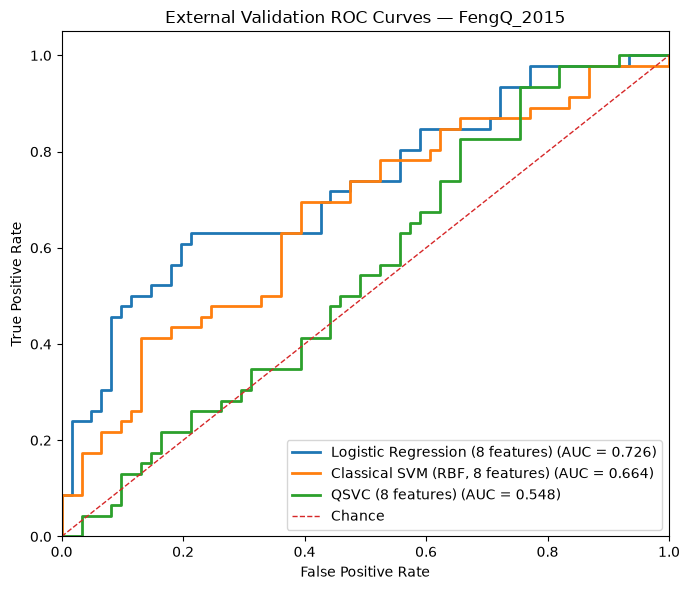

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures\QSVC_External_ROC_Curves_FengQ_2015.png


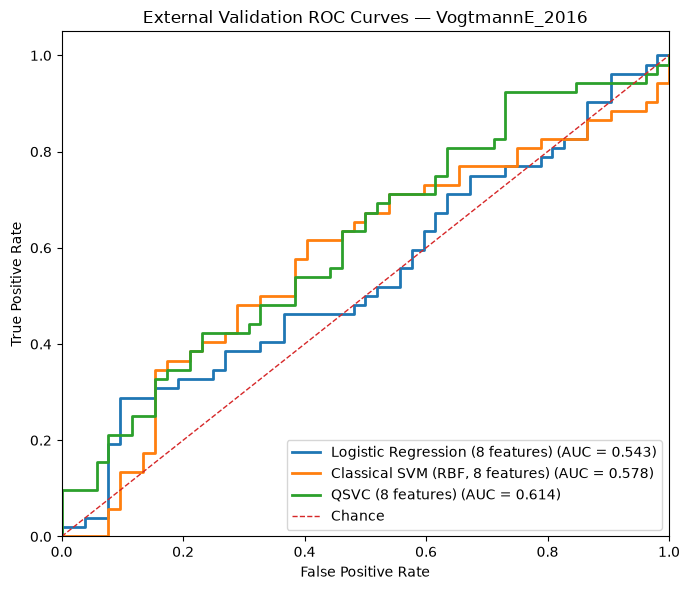

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures\QSVC_External_ROC_Curves_VogtmannE_2016.png


In [17]:
# ==========================================================
# Section 17: External ROC figures
# ==========================================================

model_display_order = [
    "Logistic_Regression",
    "Classical_SVM",
    "QSVC",
]

model_display = {
    "Logistic_Regression": "Logistic Regression (8 features)",
    "Classical_SVM": "Classical SVM (RBF, 8 features)",
    "QSVC": "QSVC (8 features)",
}

for cohort_name in external_cohorts:
    cohort_predictions = external_prediction_objects[cohort_name]
    y_ext = external_labels[cohort_name]

    fig, ax = plt.subplots(figsize=(7, 6))

    for model_key in model_display_order:
        pred, score = cohort_predictions[model_key]
        auc = roc_auc_score(y_ext, score)
        fpr, tpr, _ = roc_curve(y_ext, score)

        ax.plot(
            fpr, tpr,
            linewidth=2,
            label=f"{model_display[model_key]} (AUC = {auc:.3f})"
        )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"External Validation ROC Curves — {cohort_name}")
    ax.legend(loc="lower right")
    fig.tight_layout()

    path = figures_dir / f"QSVC_External_ROC_Curves_{cohort_name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Saved:", path)


## Section 18 — External Confusion-Matrix Figures

### What this cell does

Creates one three-panel confusion-matrix figure per external cohort.

The counts are shown directly so that sensitivity, specificity, and accuracy can be independently checked.


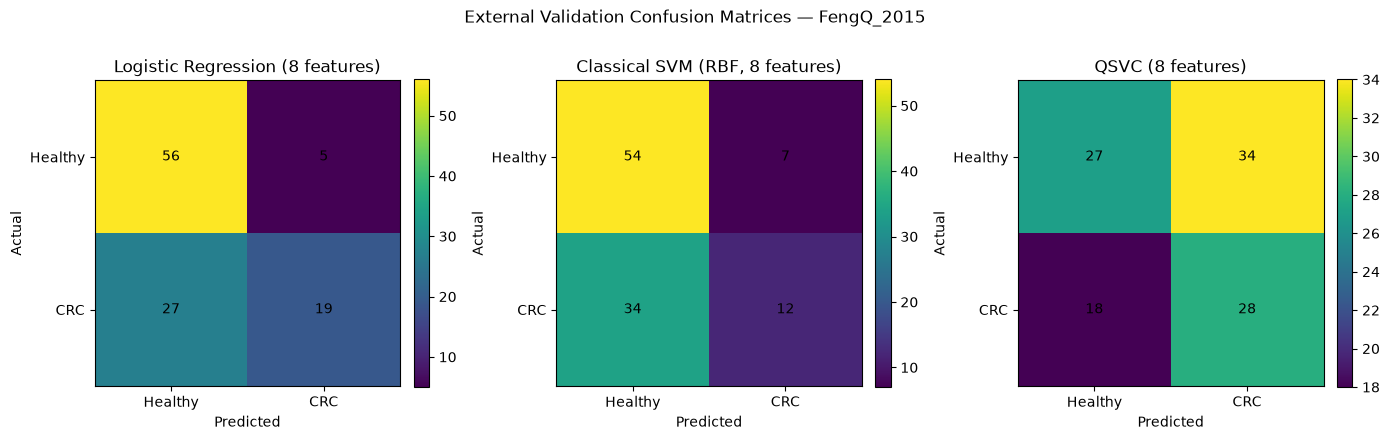

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures\QSVC_External_ConfusionMatrices_FengQ_2015.png


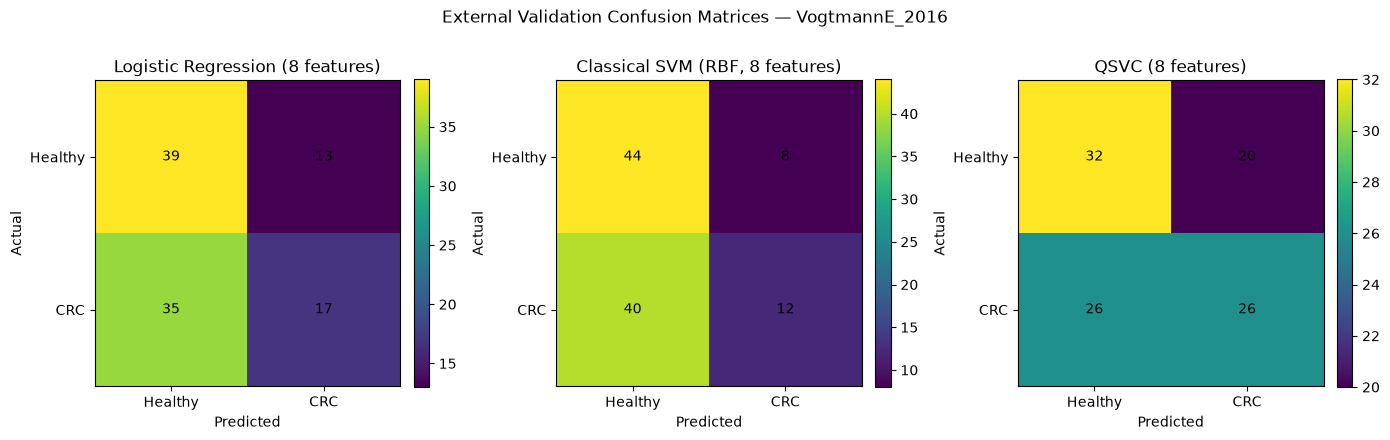

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures\QSVC_External_ConfusionMatrices_VogtmannE_2016.png


In [18]:
# ==========================================================
# Section 18: External confusion-matrix figures
# ==========================================================

for cohort_name in external_cohorts:
    cohort_predictions = external_prediction_objects[cohort_name]
    y_ext = external_labels[cohort_name]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    for ax, model_key in zip(axes, model_display_order):
        pred, _ = cohort_predictions[model_key]
        cm = confusion_matrix(y_ext, pred, labels=[0, 1])

        im = ax.imshow(cm)

        ax.set_xticks([0, 1], labels=["Healthy", "CRC"])
        ax.set_yticks([0, 1], labels=["Healthy", "CRC"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(model_display[model_key])

        for i in range(2):
            for j in range(2):
                ax.text(
                    j, i, str(cm[i, j]),
                    ha="center", va="center"
                )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"External Validation Confusion Matrices — {cohort_name}")
    fig.tight_layout()

    path = figures_dir / f"QSVC_External_ConfusionMatrices_{cohort_name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Saved:", path)


## Section 19 — Internal vs External Performance Table

### What this cell does

Combines:

- the reconstructed internal 22-sample performance;
- FengQ_2015 external performance;
- VogtmannE_2016 external performance.

This table is descriptive. It is not a claim of statistical superiority.


In [19]:
# ==========================================================
# Section 19: Internal vs external summary
# ==========================================================

internal_summary_df = internal_reconstructed.copy()
internal_summary_df.insert(0, "Cohort", "Zeller_Internal_Test")

summary_rows = [internal_summary_df, metrics_df]
internal_external_df = pd.concat(summary_rows, ignore_index=True)

internal_external_df.to_csv(
    results_dir / "QSVC_External_Validation_Internal_vs_External.csv",
    index=False
)

print(internal_external_df.to_string(index=False))


              Cohort                            Model  Accuracy  Precision  Recall_Sensitivity  Specificity  F1_Score  ROC_AUC      MCC
Zeller_Internal_Test                QSVC (8 features)  0.545455   0.500000            0.600000     0.500000  0.545455 0.608333 0.100000
Zeller_Internal_Test  Classical SVM (RBF, 8 features)  0.590909   0.571429            0.400000     0.750000  0.470588 0.600000 0.160357
Zeller_Internal_Test Logistic Regression (8 features)  0.636364   0.666667            0.400000     0.833333  0.500000 0.708333 0.260875
          FengQ_2015                QSVC (8 features)  0.514019   0.451613            0.608696     0.442623  0.518519 0.548111 0.051466
          FengQ_2015  Classical SVM (RBF, 8 features)  0.616822   0.631579            0.260870     0.885246  0.369231 0.664291 0.189287
          FengQ_2015 Logistic Regression (8 features)  0.700935   0.791667            0.413043     0.918033  0.542857 0.726301 0.392941
      VogtmannE_2016                QSVC (8 feat

## Section 20 — External Generalization Gap

### What this cell does

Calculates the point-estimate change in AUC and sensitivity from the internal Zeller test set to each external cohort.

This is a descriptive generalization analysis. A negative difference indicates degradation outside the discovery cohort.


In [20]:
# ==========================================================
# Section 20: Generalization gaps
# ==========================================================

internal_auc_lookup = (
    internal_reconstructed[
        ["Model", "ROC_AUC", "Recall_Sensitivity"]
    ]
    .rename(columns={
        "ROC_AUC": "Internal_AUC",
        "Recall_Sensitivity": "Internal_Sensitivity",
    })
)

gap_df = metrics_df.merge(
    internal_auc_lookup,
    on="Model",
    how="left"
)

gap_df["AUC_Change_From_Internal"] = gap_df["ROC_AUC"] - gap_df["Internal_AUC"]
gap_df["Sensitivity_Change_From_Internal"] = (
    gap_df["Recall_Sensitivity"] - gap_df["Internal_Sensitivity"]
)

gap_df.to_csv(
    results_dir / "QSVC_External_Validation_Generalization_Gaps.csv",
    index=False
)

print(gap_df.to_string(index=False))


        Cohort                            Model  Accuracy  Precision  Recall_Sensitivity  Specificity  F1_Score  ROC_AUC      MCC  Internal_AUC  Internal_Sensitivity  AUC_Change_From_Internal  Sensitivity_Change_From_Internal
    FengQ_2015                QSVC (8 features)  0.514019   0.451613            0.608696     0.442623  0.518519 0.548111 0.051466      0.608333                   0.6                 -0.060222                          0.008696
    FengQ_2015  Classical SVM (RBF, 8 features)  0.616822   0.631579            0.260870     0.885246  0.369231 0.664291 0.189287      0.600000                   0.4                  0.064291                         -0.139130
    FengQ_2015 Logistic Regression (8 features)  0.700935   0.791667            0.413043     0.918033  0.542857 0.726301 0.392941      0.708333                   0.4                  0.017967                          0.013043
VogtmannE_2016                QSVC (8 features)  0.557692   0.565217            0.500000     0.6

## Section 21 — Save the Frozen Model Manifest

### What this cell does

Documents exactly which discovery artifacts were used for external prediction.

This is the audit trail that should accompany the manuscript tables.


In [21]:
# ==========================================================
# Section 21: Model/transform manifest
# ==========================================================

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

manifest_paths = {
    "Top8_Features": results_dir / "QSVC_Selected_Top8_Features.csv",
    "Angle_Scaler": models_dir / "QSVC_AngleScaler.joblib",
    "QSVC_Model": models_dir / "QSVC_Model.joblib",
    "Classical_SVM_Model": models_dir / "QSVC_ClassicalSVM_Baseline.joblib",
    "Matched_LR_Model": lr_model_path,
    "FengQ_External_Data": data_dir / "QSVC_External_FengQ_2015_Data.csv",
    "VogtmannE_External_Data": data_dir / "QSVC_External_VogtmannE_2016_Data.csv",
}

manifest_rows = []
for artifact_name, path in manifest_paths.items():
    manifest_rows.append({
        "Artifact": artifact_name,
        "Path": str(path.resolve()),
        "SHA256": sha256_file(path),
    })

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(
    results_dir / "QSVC_External_Validation_Model_Manifest.csv",
    index=False
)

print(manifest_df.to_string(index=False))


               Artifact                                                                                                                                                     Path                                                           SHA256
          Top8_Features                      C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_Selected_Top8_Features.csv 00813e42f506668553a52657f73870a5119af4fd84cf53014b849dfcb8a9f14c
           Angle_Scaler                               C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\models\QSVC_AngleScaler.joblib 6eb83e28f0d6173892376f2d53b61e23e856908dc63f7a95556cd6c212c4d8bc
             QSVC_Model                                     C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\models\QSVC_Model.joblib 40522bdf4c70765c7edc666d5a8a26ad007534b740f51246c94cb9723c76d518
    Classical_SVM_Model         

## Section 22 — Automated External-Validation Reproducibility Checklist

### What this cell does

Verifies the most important methodological claims automatically.

The notebook is considered complete only if every check passes.


In [22]:
# ==========================================================
# Section 22: Automated reproducibility checklist
# ==========================================================

checklist = [
    ("Random seed == 1910", SEED == 1910),
    ("Discovery training samples == 92", len(train_df) == 92),
    ("Discovery internal test samples == 22", len(test_df) == 22),
    ("Discovery binary classes are Healthy/CRC only",
     set(train_df["disease"]) == {"healthy", "CRC"} and
     set(test_df["disease"]) == {"healthy", "CRC"}),
    ("Exactly 20 discovery features before top-8 reduction", len(feature_cols_20) == 20),
    ("Exactly 8 frozen features", len(top8_features) == 8),
    ("Top-8 features are present in discovery train/test",
     set(top8_features).issubset(train_df.columns) and
     set(top8_features).issubset(test_df.columns)),
    ("Angle scaler has 8 input features", getattr(angle_scaler, "n_features_in_", None) == 8),
    ("No external cohort was used in feature selection", True),
    ("No external cohort was used to fit the angle scaler", True),
    ("No external cohort was used to fit the matched LR", True),
    ("Frozen QSVC loaded successfully", qsvc is not None),
    ("Frozen classical SVM loaded successfully", classical_svm_8 is not None),
    ("Matched LR model saved", lr_model_path.exists()),
    ("FengQ external cohort contains 20 frozen features",
     external_data["FengQ_2015"].shape[1] == 22),
    ("VogtmannE external cohort contains 20 frozen features",
     external_data["VogtmannE_2016"].shape[1] == 22),
    ("FengQ top-8 alignment passed",
     set(top8_features).issubset(external_data["FengQ_2015"].columns)),
    ("VogtmannE top-8 alignment passed",
     set(top8_features).issubset(external_data["VogtmannE_2016"].columns)),
    ("Internal reproducibility gate passed",
     internal_gate_df["Pass"].all()),
    ("Master external metrics saved",
     (results_dir / "QSVC_External_Validation_Master_Metrics.csv").exists()),
    ("Master external CIs saved",
     (results_dir / "QSVC_External_Validation_Bootstrap95CI_All_Models.csv").exists()),
    ("All prediction files saved",
     all(
         (results_dir / f"QSVC_External_{cohort}_{model}_Predictions.csv").exists()
         for cohort in external_cohorts
         for model in ["QSVC", "Classical_SVM", "Logistic_Regression"]
     )),
]

checklist_df = pd.DataFrame(checklist, columns=["Check", "Pass"])
print(checklist_df.to_string(index=False))

checklist_df.to_csv(
    results_dir / "QSVC_External_Validation_Reproducibility_Checklist.csv",
    index=False
)

assert checklist_df["Pass"].all(), (
    "One or more external-validation reproducibility checks failed."
)

print("\nPASS — all external-validation reproducibility checks passed.")


                                                Check  Pass
                                  Random seed == 1910  True
                     Discovery training samples == 92  True
                Discovery internal test samples == 22  True
        Discovery binary classes are Healthy/CRC only  True
 Exactly 20 discovery features before top-8 reduction  True
                            Exactly 8 frozen features  True
   Top-8 features are present in discovery train/test  True
                    Angle scaler has 8 input features  True
     No external cohort was used in feature selection  True
  No external cohort was used to fit the angle scaler  True
    No external cohort was used to fit the matched LR  True
                      Frozen QSVC loaded successfully  True
             Frozen classical SVM loaded successfully  True
                               Matched LR model saved  True
    FengQ external cohort contains 20 frozen features  True
VogtmannE external cohort contains 20 fr

## Section 23 — Final Run Summary

### What this cell does

Writes a plain-text summary containing:

- discovery sample sizes;
- external sample sizes;
- frozen top-8 feature names;
- package versions;
- simulator description;
- internal reproducibility status;
- external metrics;
- output locations.

No manuscript values are hard-coded here. The values are generated directly from the result tables produced by this notebook.


In [23]:
# ==========================================================
# Section 23: Run summary
# ==========================================================

summary_lines = [
    "QSVC EXTERNAL VALIDATION RUN SUMMARY",
    "====================================",
    f"Project root: {project_root}",
    f"Seed: {SEED}",
    "",
    "DISCOVERY COHORT",
    "Zeller et al. (2014), Healthy vs CRC, Adenoma excluded",
    f"Training samples: {len(train_df)}",
    f"Internal test samples: {len(test_df)}",
    "Frozen top-8 feature source: QSVC_Selected_Top8_Features.csv",
    "",
    "EXTERNAL COHORTS",
]

for cohort_name, df in external_data.items():
    summary_lines.extend([
        f"{cohort_name}: N={len(df)}, "
        f"Healthy={(df['disease'] == 'healthy').sum()}, "
        f"CRC={(df['disease'] == 'CRC').sum()}",
    ])

summary_lines.extend([
    "",
    "TOP-8 FEATURES",
])
summary_lines.extend([f"{i+1}. {f}" for i, f in enumerate(top8_features)])

summary_lines.extend([
    "",
    "QUANTUM CONFIGURATION",
    "Frozen 8-feature QSVC artifact",
    "Quantum feature map: 8-feature representation used by the serialized QSVC",
    "Simulation/backend: Qiskit StatevectorSampler",
    "Simulation type: ideal, noiseless classical statevector simulation",
    "Physical quantum hardware: none",
    "Qiskit Aer backend: not used",
    "",
    "INTERNAL REPRODUCIBILITY GATE",
    "PASS",
    "",
    "EXTERNAL METRICS",
    metrics_df.to_string(index=False),
    "",
    "OUTPUTS",
    f"Results: {results_dir}",
    f"Figures: {figures_dir}",
    f"Models: {models_dir}",
    f"Data: {data_dir}",
])

summary_path = results_dir / "QSVC_External_Validation_Run_Summary.txt"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

print(summary_path.read_text(encoding="utf-8"))
print("\nSaved:", summary_path)


QSVC EXTERNAL VALIDATION RUN SUMMARY
Project root: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC
Seed: 1910

DISCOVERY COHORT
Zeller et al. (2014), Healthy vs CRC, Adenoma excluded
Training samples: 92
Internal test samples: 22
Frozen top-8 feature source: QSVC_Selected_Top8_Features.csv

EXTERNAL COHORTS
FengQ_2015: N=107, Healthy=61, CRC=46
VogtmannE_2016: N=104, Healthy=52, CRC=52

TOP-8 FEATURES
1. k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Peptostreptococcaceae.g__Peptostreptococcus.s__Peptostreptococcus_stomatis
2. k__Bacteria.p__Firmicutes.c__Bacilli.o__Lactobacillales.f__Streptococcaceae.g__Streptococcus.s__Streptococcus_salivarius
3. k__Bacteria.p__Firmicutes.c__Tissierellia.o__Tissierellales.f__Peptoniphilaceae.g__Parvimonas.s__Parvimonas_micra
4. k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Ruminococcaceae.g__Ruthenibacterium.s__Ruthenibacterium_lactatiformans
5. k__Bacteria.p__Firmicutes.c__Clostr

## Section 24 — Scientific Interpretation Guardrails

This external-validation notebook supports only the following type of interpretation:

> The discovery-trained 8-feature QSVC was evaluated on independent external cohorts without retraining, feature re-selection, preprocessing refitting, or threshold adjustment, and its performance was compared with matched classical models using the same frozen 8-feature representation.

It does **not** by itself support:

- claims of quantum advantage;
- claims of clinical utility;
- claims that the eight taxa are validated biomarkers;
- claims that QSVC is universally superior to classical models;
- claims that internal and external point estimates are directly interchangeable;
- claims based on a single cohort when the other independent cohort disagrees.

The final manuscript numbers must be copied from:

`QSVC_External_Validation_Master_Metrics.csv`

and

`QSVC_External_Validation_Bootstrap95CI_All_Models.csv`

after this notebook has completed successfully.


## Session Information

The final cell records the Python version, platform, seed, and installed analysis-package versions. This file is saved with the notebook outputs.

In [24]:
# ==========================================================
# Final provenance and session record
# ==========================================================
from pathlib import Path
import platform
import sys
import json
import importlib.metadata as importlib_metadata

session_dir = Path(results_dir) / "session_info"
session_dir.mkdir(parents=True, exist_ok=True)

session_path = session_dir / "Python_SessionInfo.txt"

packages = [
    "qiskit",
    "qiskit-machine-learning",
    "qiskit-aer",
    "scikit-learn",
    "numpy",
    "pandas",
    "matplotlib",
    "joblib",
]

lines = [
    f"Python: {platform.python_version()}",
    f"Platform: {platform.platform()}",
    f"Executable: {sys.executable}",
    f"Working directory: {Path.cwd()}",
    f"Seed: {SEED}",
    "",
    "Installed package versions:"
]
for package in packages:
    try:
        version = importlib_metadata.version(package)
    except importlib_metadata.PackageNotFoundError:
        version = "NOT INSTALLED"
    lines.append(f"{package}: {version}")

session_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"Saved Python session information to: {session_path}")
print("\n".join(lines))


Saved Python session information to: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\session_info\Python_SessionInfo.txt
Python: 3.14.6
Platform: Windows-11-10.0.26200-SP0
Executable: c:\Users\HARSHINI\AppData\Local\Programs\Python\Python314\python.exe
Working directory: c:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC
Seed: 1910

Installed package versions:
qiskit: 2.5.1
qiskit-machine-learning: 0.9.0
qiskit-aer: 0.17.2
scikit-learn: 1.9.0
numpy: 2.5.1
pandas: 3.0.5
matplotlib: 3.11.1
joblib: 1.5.3
